In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D  
import figurefirst as fifi
import seaborn as sns
###
import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *
from BayesFactorFunctions import *


from tsfresh import defaults, extract_features
from tsfresh.feature_selection.relevance import calculate_relevance_table
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import MinimalFCParameters #
 
import umap


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


# Set params and load FiFi template

In [2]:
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


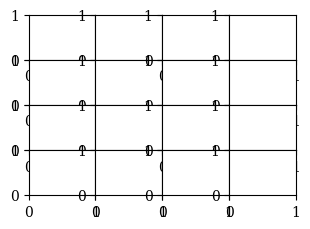

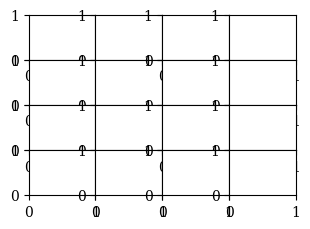

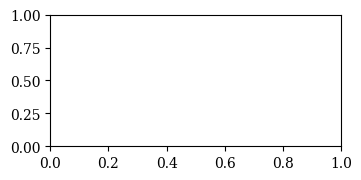

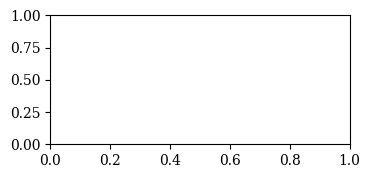

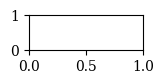

In [3]:
layout = fifi.svg_to_axes.FigureLayout('../f7_bayes.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])


# Steady, low

In [4]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [5]:
bottom_on_df['ground speed']= np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [6]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [7]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

# Unsteady, low

In [8]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [9]:
top_on_df['ground speed'] = np.sqrt(top_on_df['xvel']**2 + top_on_df['yvel']**2)

In [10]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [11]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

# Casting sims in CFD

In [12]:
casting_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_merged_casting_2025-01-07.hdf')

In [13]:
unsteady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_casting = casting_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


# Circle Sims in CFD

In [14]:
circle_sims_cfd = pd.read_hdf('../../../Data/Simulated_Trajectory_Data/cfd_sim_results_merged_circling_2025-01-07.hdf')

In [15]:
unsteady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.max()<.25).reset_index(drop=True)
steady_circle = circle_sims_cfd.groupby('obj_id_unique').filter(lambda d: d.z.min()>.25).reset_index(drop=True)


# Features; UMAP

In [16]:
np.random.seed(100)
dfs = [
       flash_low_bottom_on, 
       flash_low_top_on,
       flash_up_top_on, 
       flash_up_bottom_on, 
      
       unsteady_casting[unsteady_casting.obj_id_unique.isin(np.random.choice(unsteady_casting.obj_id_unique.unique(),500,replace=False))],
      steady_casting[steady_casting.obj_id_unique.isin(np.random.choice(steady_casting.obj_id_unique.unique(),500,replace=False))],
      unsteady_circle[unsteady_circle.obj_id_unique.isin(np.random.choice(unsteady_circle.obj_id_unique.unique(),500,replace=False))],
      steady_circle[steady_circle.obj_id_unique.isin(np.random.choice(steady_circle.obj_id_unique.unique(),500,replace=False))],]


In [17]:
dfs = calculate_features(dfs, start_time=1100)

df # 0
Culled 45 trajectories
n trajs: 255
df # 1
Culled 88 trajectories
n trajs: 231
df # 2
Culled 20 trajectories
n trajs: 115
df # 3
Culled 7 trajectories
n trajs: 99
df # 4
Culled 0 trajectories
n trajs: 500
df # 5
Culled 0 trajectories
n trajs: 500
df # 6
Culled 5 trajectories
n trajs: 500
df # 7
Culled 3 trajectories
n trajs: 500


In [18]:
all_dfs = pd.concat(dfs)

In [19]:
X = extract_features(all_dfs[['xvel','yvel', 'normed_x_680', 'normed_y_680','obj_id_unique','time stamp']].dropna(), 
                         column_id='obj_id_unique', column_sort='time stamp',
                         #default_fc_parameters=ComprehensiveFCParameters(),
                         default_fc_parameters=MinimalFCParameters(),
                     impute_function=impute)

# these are just the length of each time series, not relevant features
X = X.drop(columns=['xvel__length','yvel__length','normed_x_680__length','normed_y_680__length'])


2025-01-11 14:48:32,164 [WARNING] Dependency not available for matrix_profile, this feature will be disabled!
Feature Extraction: 100%|██████████████████████████████████████████████████████████| 80/80 [00:01<00:00, 40.75it/s]


In [20]:
cmap_sim = plt.get_cmap('BrBG', 16) 
cmap_real = plt.get_cmap('RdBu', 16) 



df_colors = [ 
             'darkorange',
            cmap_real(13),
             cmap_real(4),
            cmap_real(12),
            
             cmap_sim(13),
            cmap_sim(3),
             cmap_sim(12),
            cmap_sim(4),]





df_labels = [
             'Steady, z < 0.25m', #4
             'Unsteady, z < 0.25m', #5
             'Steady, z > 0.25m', #6
             'Unsteady, z > 0.25m', #7
           
             
      'Casting Sim, Unsteady', #8
      'Casting Sim, Steady', #9
      'Circling Sim, Unsteady', #10
      'Circling Sim, Steady',] #11


df_features_list = []



feature_names = ['circle_cross', 
                 'hull_area', 
                 'hull_roundness', 
                 'heading_derivative_absmean',
                 'heading_difference_sliding_absmean',]


for i, df in enumerate(dfs):
    df['dataset_name'] = df_labels[i]
    df_features = df.groupby('obj_id_unique')['dataset_name'].first()
    
    for feature_name in feature_names:
        df_tmp = np.abs( df.groupby('obj_id_unique')[feature_name].mean() )
        df_features = pd.concat([df_features, df_tmp], axis=1)
    df_features['class']=i
    df_features =df_features.assign(color=df_features.apply(lambda x: df_colors[i], 1))
    df_features_list.append(df_features)
    
df_features = pd.concat(df_features_list)

In [21]:
dfs_important_feats = df_features.join(X)

In [22]:
## irrel features found in f5
irrel_feats_mannu = ['normed_y_680__mean', 'normed_y_680__sum_values', 'normed_y_680__median']

# Import Model Trained on Lam + Still Air Data

In [23]:
import pickle
f_name = '../../../Code/UMAP_trained.sav'
trained_model = pickle.load((open(f_name, 'rb')))
print(type(trained_model))


<class 'umap.umap_.UMAP'>


In [24]:
# Unsteady + steady (real)
X_test = StandardScaler().fit_transform(dfs_important_feats[dfs_important_feats.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', ])].sort_index().drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu).values)
realdf = dfs_important_feats[dfs_important_feats.dataset_name.isin(['Steady, z < 0.25m', 'Unsteady, z < 0.25m', ])].sort_index().copy()
#X_test  =StandardScaler().fit_transform(X_test.values)
y_test =  dfs_important_feats[dfs_important_feats.dataset_name.isin([ 'Steady, z < 0.25m', 'Unsteady, z < 0.25m',])]['color'].sort_index() 
test_embedding = trained_model.transform(X_test)
realdf['embedding_x'] = test_embedding[:, 0]
realdf['embedding_y'] =test_embedding[:, 1]




# Unsteady + steady (simulations)
simdf = dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady',
      ])].sort_index().copy()
X_test1 =StandardScaler().fit_transform( dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady', 
       ])].drop(columns=['dataset_name', 'color','class', ] + irrel_feats_mannu).sort_index().values)
y_test1 =  dfs_important_feats[dfs_important_feats.dataset_name.isin([
       'Circling Sim, Steady', 'Casting Sim, Unsteady', 'Circling Sim, Unsteady', 'Casting Sim, Steady', 
       ])]['color'].sort_index()
test_embedding1 = trained_model.transform(X_test1)
simdf['embedding_x'] = test_embedding1[:, 0]
simdf['embedding_y'] =test_embedding1[:, 1]


# Calculate Gaussian Kernels

In [28]:
x = np.arange(0, 15, 0.05)
y = np.arange(6, 14, 0.05)

X,Y = np.meshgrid(x,y)


kernel_sigma =1
contour_number_for_plot = 5
greys = color_fade(hex2rgb("#000000"), contour_number_for_plot)
all_gaussians_summed = sum(normal_kernel_2D(X,Y, point, kernel_sigma,kernel_sigma) for point in zip(simdf[simdf['dataset_name']=='Casting Sim, Unsteady']['embedding_x'], simdf[simdf['dataset_name']=='Casting Sim, Unsteady']['embedding_y']))
area_under_all_gaussians = float(np.sum(all_gaussians_summed))
pdf_normalized_lam = all_gaussians_summed/area_under_all_gaussians
print (np.sum(pdf_normalized_lam)) # should sum to 1.0

all_gaussians_summed = sum(normal_kernel_2D(X,Y, point, kernel_sigma,kernel_sigma) for point in zip(simdf[simdf['dataset_name']=='Circling Sim, Unsteady']['embedding_x'], simdf[simdf['dataset_name']=='Circling Sim, Unsteady']['embedding_y']))
area_under_all_gaussians = float(np.sum(all_gaussians_summed))
pdf_normalized_nw = all_gaussians_summed/area_under_all_gaussians
print (np.sum(pdf_normalized_nw)) # should sum to 1.0

0.9999999999999999
1.0


(0.0, 15.0, 5.0, 14.0)

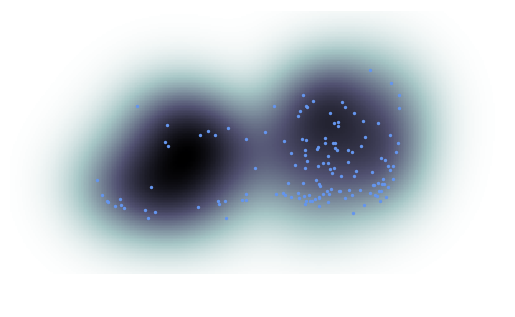

In [73]:
fig,ax=plt.subplots()
ax.set_ylim(5, 14)
ax.set_xlim(0, 15)

#ax = layout.axes[('A', 'a')]

ax.contour(X, Y, pdf_normalized_lam, levels = [0.99], colors ='black' , zorder = 0)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.imshow(pdf_normalized_lam, cmap='bone_r', interpolation='nearest', origin='lower', extent = (X.min(), X.max(), Y.min(), Y.max())) #cmap was 'binary'

ax.scatter(realdf[realdf['dataset_name']=='Unsteady, z < 0.25m']['embedding_x'], realdf[realdf['dataset_name']=='Unsteady, z < 0.25m']['embedding_y'], color = 'cornflowerblue', zorder = 1, s = 2) 

adjust_spines(ax_handle=ax, spines= ['bottom', 'left'])


ax.axis('off')
#layout.append_figure_to_layer(layout.figures['A'], 'A', cleartarget=True)

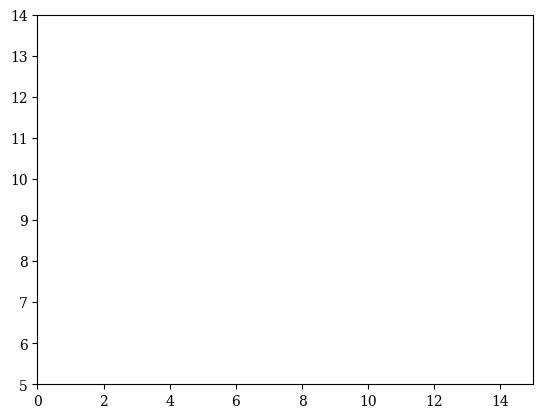

In [30]:
fig,ax=plt.subplots()
ax.set_ylim(5, 14)
ax.set_xlim(0, 15)

ax = layout.axes[('B', 'b')]

ax.contour(X, Y, pdf_normalized_nw, levels = [0.99], colors ='black' , zorder = 10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.imshow(pdf_normalized_nw, cmap='bone_r', interpolation='nearest', origin='lower', extent = (X.min(), X.max(), Y.min(), Y.max())) #cmap was 'binary'

ax.scatter(realdf[realdf['dataset_name']=='Unsteady, z < 0.25m']['embedding_x'], realdf[realdf['dataset_name']=='Unsteady, z < 0.25m']['embedding_y'], color = 'cornflowerblue', zorder = 1, s = 2) 

adjust_spines(ax_handle=ax, spines= ['bottom', 'left'])

ax.axis('off')

layout.append_figure_to_layer(layout.figures['B'], 'B', cleartarget=True)

In [31]:
resample_number = 50000
list_of_log_Bayes_factors = np.zeros(resample_number)
embedding_x = realdf[realdf.dataset_name.isin(['Unsteady, z < 0.25m',])].embedding_x.values
embedding_y = realdf[realdf.dataset_name.isin(['Unsteady, z < 0.25m',])].embedding_y.values
for i in range(resample_number):
    resampled_indices = np.random.choice(len(embedding_x),len(embedding_x), replace = True)
    list_of_log_likelihood_ratios =[]
    for idx in resampled_indices:
        x_index = find_nearest_index(x, embedding_x[idx])
        y_index = find_nearest_index(y, embedding_y[idx])
        list_of_log_likelihood_ratios.append(np.log(pdf_normalized_nw[y_index, x_index]/pdf_normalized_lam[y_index, x_index]))
    log_Bayes_factor = np.sum(list_of_log_likelihood_ratios)
    list_of_log_Bayes_factors[i] = log_Bayes_factor

Bayes factor mean:18.100992747518777


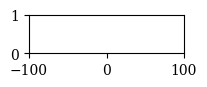

In [32]:
fig,ax = plt.subplots(figsize= (2,.5))
ax = layout.axes[('C', 'c')]
hist_factor = -2.
binwidth = 30

binlist = range(int(min(list_of_log_Bayes_factors)), int(max(list_of_log_Bayes_factors))+binwidth, binwidth)
ax.hist(list_of_log_Bayes_factors, bins = 50, color = 'k', weights=(10**hist_factor)*np.ones_like(list_of_log_Bayes_factors), histtype = 'step',)

print ('Bayes factor mean:'+str(np.mean(list_of_log_Bayes_factors)))

    

ax.set_xlim(-100, 100)
plt.xticks(np.linspace(-100, 100, 3, endpoint = True))
ax.spines['bottom'].set_bounds(-100, 100)
ax.text(-40,60,  'ln $\dfrac{L(circling)}{L(casting)}$', fontsize=8)


# ax.text(600,105, str(np.mean(list_of_log_Bayes_factors)) )
# ax.text(600,75,str(np.mean(list_of_log_Bayes_factors_outliers_omitted)) )
adjust_spines(ax_handle=ax, spines= ['bottom'])

layout.append_figure_to_layer(layout.figures['C'], 'C', cleartarget=True)

In [35]:
layout.write_svg('f7_bayes.svg')